# Regression Using Tensorflow and Deep Learning

- Input layer shape
- Hidden layer(s)
- Neurons per hidden..layer
- Output layer shape
- Hidden activation
- output activation
- loss function
- optimizer

In [49]:
import tensorflow as tf
print(tf.__version__)

2.20.0


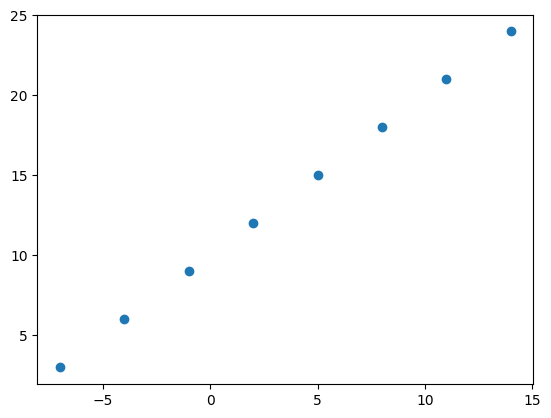

In [66]:
import numpy as np
import matplotlib.pyplot as plt

X = tf.constant(np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0]))
y = tf.constant(np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0]))

plt.scatter(X, y)

In [67]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape # Output is ((), ()) because the dimention is 0, scalar tensors

(TensorShape([]), TensorShape([]))

## Steps in modeling with tensorflow


In [68]:
tf.random.set_seed(42)


# 1. Create a model using the sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. compile the model
model.compile(loss=tf.keras.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=['mae'])

# Reshape X to be compatible with the Dense layer (add an extra dimension)
X_reshaped = tf.expand_dims(X, axis=-1)

# 3. Fit the model
model.fit(X_reshaped, y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - loss: 10.7965 - mae: 10.7965
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 10.6640 - mae: 10.6640
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 10.5315 - mae: 10.5315
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 10.3990 - mae: 10.3990
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 10.2665 - mae: 10.2665


In [69]:
# Making prediction
model.predict(tf.expand_dims(tf.constant([17.0]), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


array([[16.156487]], dtype=float32)

# Improving the model

we can improve our model, by altering the steps we took to create a model.
1. **Creating a model** - add more layers, increase the number of hidden units (all called neurons) within each of the hidden layers, change activation functions of each layer
2. **Compiling a model**: here we might change the opimization function or perhaps the learning rate
3. **Fitting a model**: increase the number of epochs


### Improvement 1

In [70]:
# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

# 3. Fit the model
model.fit(X_reshaped, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - loss: 20.4946 - mae: 20.4946
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 20.2133 - mae: 20.2133
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 19.9321 - mae: 19.9321
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 19.6508 - mae: 19.6508
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 19.3696 - mae: 19.3696
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 19.0883 - mae: 19.0883
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 18.8071 - mae: 18.8071
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 18.5258 - mae: 18.5258
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 18.2446 - mae: 18.2446
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 17.9633 - mae: 17.9633
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 17.6821 - mae: 17.6821
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 17.4008 - mae: 17.4008
Epoch 13/100
1/1 ━━━━━━━

In [71]:
model.predict(tf.expand_dims(tf.constant([17.0]), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[29.667261]], dtype=float32)

### Improvement 2


What does each Dense mean, tf.keras.layers.Dense mean, and its parameters mean

In [83]:
# Create Model

model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None),
    # tf.keras.layers.Dense(100, activation='relu'),
    # tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss=tf.keras.losses.mae,
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               metrics=['mae'])

model.fit(X_reshaped, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 991ms/step - loss: 13.6366 - mae: 13.6366
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 12.9604 - mae: 12.9604
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 12.2918 - mae: 12.2918
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 11.6295 - mae: 11.6295
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 10.9718 - mae: 10.9718
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 10.3158 - mae: 10.3158
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 9.6587 - mae: 9.6587
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 8.9975 - mae: 8.9975
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8.3290 - mae: 8.3290
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 7.6495 - mae: 7.6495
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 6.9551 - mae: 6.9551
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 6.7210 - mae: 6.7210
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━

In [84]:
data = tf.expand_dims(tf.constant([17.0]), axis=-1)
model.predict(data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


array([[28.091553]], dtype=float32)

The matrices that we are seeing while training might not be representative of the actual learning of the model

If add more neurons (layers) or epoches don't improve our model what does? how to know better what does and what does not?

Learning rate is the most imporatnt

More about adjusting Hyperparameters


## Evaluating a Models predictions

In [86]:
X = tf.range(-100, 100, 4)
y = X + 10

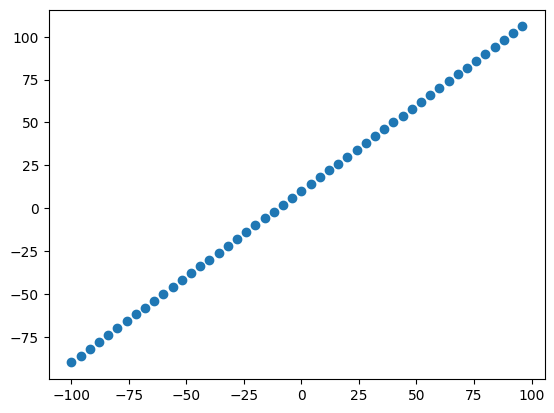

In [90]:
plt.scatter(X, y)

## The 3 Sets
- Training Set
- Validation Set
- Test Set

In [106]:
len(X)


X_train = X[:40]
y_train = y[:40]

X_test = X[40:]
y_test = y[40:]

X_train, y_train, X_test, y_test

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([60, 64, 68, 72, 76, 80, 84, 88, 92, 96], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

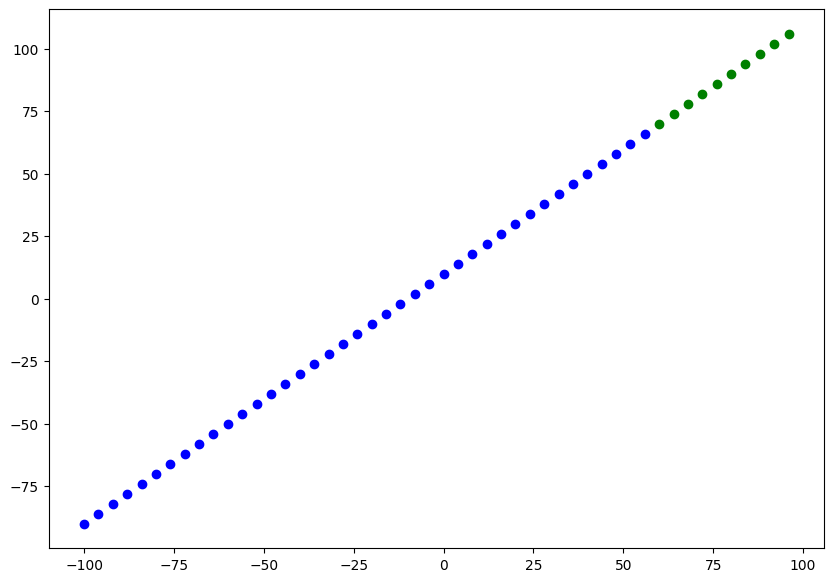

In [104]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c='blue', label="Training Data")
plt.scatter(X_test, y_test, c='green', label="Testing Data")

In [109]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

model.fit(X_train, y_train, epochs=50)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 80.1479 - mae: 80.1479 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 45.4362 - mae: 45.4362
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 14.3067 - mae: 14.3067
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.3196 - mae: 9.3196
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.4256 - mae: 8.4256
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.0977 - mae: 9.0977
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.9323 - mae: 7.9323
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 10.8728 - mae: 10.8728
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 7.6834 - mae: 7.6834
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 11.9226 - mae: 11.9226
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.3476 - mae: 8.3476
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8.8612 - mae: 8.8612
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 

Create a model which builds automatically by defining the input_shape argument in the first layer, how to define the input shape?

what does the verbose, fit argument does

In [110]:
model.summary()

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Practice


In [58]:
from sklearn.datasets import fetch_california_housing
data_frame = fetch_california_housing(as_frame=True)
df = data_frame.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [59]:
X = tf.constant(df.drop('MedHouseVal', axis=1).values)
y = tf.constant(df['MedHouseVal'].values)

X, y

(<tf.Tensor: shape=(20640, 8), dtype=float64, numpy=
 array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]])>,
 <tf.Tensor: shape=(20640,), dtype=float64, numpy=array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])>)